In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
results_path = project_path + '/results'
models_path = project_path + '/models'

print("Project path:", project_path)
print("Results path exists:", os.path.exists(results_path))
print("Models path exists:", os.path.exists(models_path))

Mounted at /content/drive
Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Results path exists: True
Models path exists: True


#Load the LSTM results

In [2]:
lstm_results_path = results_path + "/lstm_autoencoder_evaluation_A8.csv"

lstm_results = pd.read_csv(lstm_results_path)

print("LSTM evaluation results:")
print(lstm_results)

LSTM evaluation results:
  channel            method  window_size  \
0     A-8  LSTM Autoencoder           50   

                                   threshold_method  threshold  precision  \
0  99th percentile of training reconstruction error   0.116136   0.277507   

     recall  f1_score  false_positive_rate  false_negative_rate  TN    FP  \
0  0.447977  0.342714              0.98208             0.552023  81  4439   

     FN    TP  
0  2101  1705  


#Load the saved LSTM model and test data

This cell rebuilds the same model architecture and loads the trained weights from GitHub/Drive. We need the reconstruction errors for deeper analysis.

In [3]:
import torch
import torch.nn as nn

sequence_path = results_path + "/time_series_windows_A8.npz"

data = np.load(sequence_path)

X_train = data["X_train"]
X_test = data["X_test"]
test_window_labels = data["test_window_labels"]
window_size = int(data["window_size"])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, latent_size=16):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = nn.Linear(hidden_size, latent_size)

        self.decoder_fc = nn.Linear(latent_size, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(hidden[-1])

        decoder_input = self.decoder_fc(latent)
        decoder_input = decoder_input.unsqueeze(1)
        decoder_input = decoder_input.repeat(1, x.size(1), 1)

        decoded_sequence, _ = self.decoder(decoder_input)

        output = self.output_layer(decoded_sequence)

        return output


model = LSTMAutoencoder()

model_path = models_path + "/lstm_autoencoder_A8.pt"
model.load_state_dict(torch.load(model_path, map_location="cpu"))

model.eval()

with torch.no_grad():
    train_reconstructed = model(X_train_tensor)
    test_reconstructed = model(X_test_tensor)

print("Model loaded successfully.")
print("Training reconstruction shape:", train_reconstructed.shape)
print("Test reconstruction shape:", test_reconstructed.shape)

Model loaded successfully.
Training reconstruction shape: torch.Size([713, 50, 1])
Test reconstruction shape: torch.Size([8326, 50, 1])


#Calculate reconstruction errors

Now we calculate one reconstruction-error value for each 50-step window.

In [4]:
train_errors = torch.mean(
    (X_train_tensor - train_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

test_errors = torch.mean(
    (X_test_tensor - test_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

print("Training errors shape:", train_errors.shape)
print("Test errors shape:", test_errors.shape)

print("\nTraining error:")
print("Mean:", train_errors.mean())
print("Max:", train_errors.max())

print("\nTest error:")
print("Mean:", test_errors.mean())
print("Max:", test_errors.max())

Training errors shape: (713,)
Test errors shape: (8326,)

Training error:
Mean: 0.006028462
Max: 0.17965534

Test error:
Mean: 1.1909478
Max: 2.3443575


|               | Training |       Test |
| ------------- | -------: | ---------: |
| Mean error    |   0.0060 | **1.1909** |
| Maximum error |   0.1797 | **2.3444** |


The test reconstruction error is much larger than the training error. This suggests the model is seeing test patterns that are substantially different from what it learned during training.

##Compare normal vs labeled anomaly errors

Remember, A-8's ground-truth anomaly begins at test index 4569. Our window labels already account for the 50-step window alignment.

In [5]:
normal_errors = test_errors[test_window_labels == 0]
anomaly_errors = test_errors[test_window_labels == 1]

print("Normal windows:", len(normal_errors))
print("Anomaly windows:", len(anomaly_errors))

print("\nNormal reconstruction error:")
print("Mean:", normal_errors.mean())
print("Median:", np.median(normal_errors))
print("Max:", normal_errors.max())

print("\nAnomaly reconstruction error:")
print("Mean:", anomaly_errors.mean())
print("Median:", np.median(anomaly_errors))
print("Max:", anomaly_errors.max())

Normal windows: 4520
Anomaly windows: 3806

Normal reconstruction error:
Mean: 1.6910884
Median: 1.943351
Max: 2.2299805

Anomaly reconstruction error:
Mean: 0.5969814
Median: 0.07819012
Max: 2.3443575


The LSTM Autoencoder has higher reconstruction error on the labeled normal windows than on the labeled anomaly windows:

|              |     Normal |    Anomaly |
| ------------ | ---------: | ---------: |
| Mean error   | **1.6911** | **0.5970** |
| Median error | **1.9434** | **0.0782** |
| Maximum      |     2.2300 |     2.3444 |



##Reconstruction error over time

This will show us where the model produces high and low errors and where the ground-truth anomaly begins.

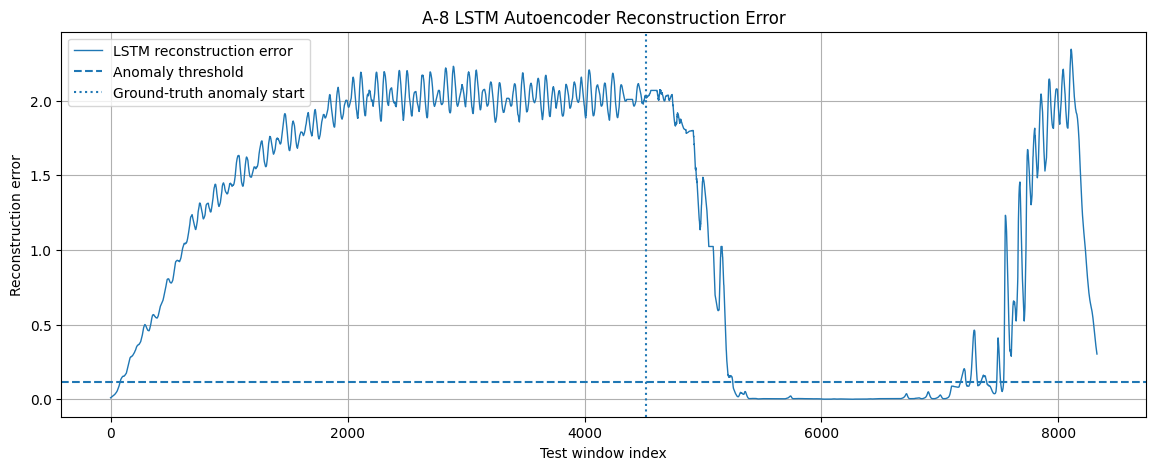

In [6]:
threshold = float(lstm_results["threshold"].iloc[0])

plt.figure(figsize=(14, 5))

plt.plot(
    test_errors,
    label="LSTM reconstruction error",
    linewidth=1
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Anomaly threshold"
)

anomaly_window_start = 4569 - window_size + 1

plt.axvline(
    anomaly_window_start,
    linestyle=":",
    label="Ground-truth anomaly start"
)

plt.xlabel("Test window index")
plt.ylabel("Reconstruction error")
plt.title("A-8 LSTM Autoencoder Reconstruction Error")
plt.legend()
plt.grid(True)

plt.show()

##Quantify the error difference

Let's calculate the ratio between normal and anomaly mean reconstruction error. This gives us one simple numerical measure for our research notes.

In [7]:
error_ratio = normal_errors.mean() / anomaly_errors.mean()

print("Normal mean error:", normal_errors.mean())
print("Anomaly mean error:", anomaly_errors.mean())
print("Normal-to-anomaly error ratio:", error_ratio)

Normal mean error: 1.6910884
Anomaly mean error: 0.5969814
Normal-to-anomaly error ratio: 2.8327322


##Now we will Create a confusion matrix

Confusion Matrix:
[[  81 4439]
 [2101 1705]]


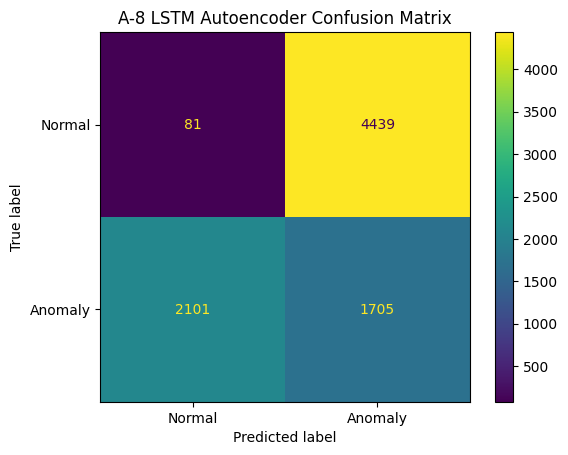

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_window_labels
y_pred = (test_errors > threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("A-8 LSTM Autoencoder Confusion Matrix")
plt.show()

##Compare Autoencoder vs LSTM Autoencoder

Now let's put our two reconstruction-based models side by side

In [9]:
autoencoder_result = pd.read_csv(
    results_path + "/autoencoder_evaluation_A8.csv"
)

comparison = pd.DataFrame({
    "Model": [
        "Autoencoder",
        "LSTM Autoencoder"
    ],
    "Precision": [
        autoencoder_result["precision"].iloc[0],
        lstm_results["precision"].iloc[0]
    ],
    "Recall": [
        autoencoder_result["recall"].iloc[0],
        lstm_results["recall"].iloc[0]
    ],
    "F1 Score": [
        autoencoder_result["f1_score"].iloc[0],
        lstm_results["f1_score"].iloc[0]
    ],
    "False Positive Rate": [
        autoencoder_result["false_positive_rate"].iloc[0],
        lstm_results["false_positive_rate"].iloc[0]
    ]
})

print(comparison)

              Model  Precision    Recall  F1 Score  False Positive Rate
0       Autoencoder   0.320945  0.567262  0.409950             0.999781
1  LSTM Autoencoder   0.277507  0.447977  0.342714             0.982080


##Save the SERIAL 24 analysis summary

In [10]:
analysis_summary = pd.DataFrame({
    "channel": ["A-8"],
    "normal_mean_error": [normal_errors.mean()],
    "anomaly_mean_error": [anomaly_errors.mean()],
    "normal_median_error": [np.median(normal_errors)],
    "anomaly_median_error": [np.median(anomaly_errors)],
    "normal_to_anomaly_error_ratio": [error_ratio],
    "lstm_precision": [lstm_results["precision"].iloc[0]],
    "lstm_recall": [lstm_results["recall"].iloc[0]],
    "lstm_f1_score": [lstm_results["f1_score"].iloc[0]],
    "lstm_false_positive_rate": [lstm_results["false_positive_rate"].iloc[0]],
    "lstm_false_negative_rate": [lstm_results["false_negative_rate"].iloc[0]]
})

analysis_path = results_path + "/lstm_autoencoder_analysis_A8.csv"

analysis_summary.to_csv(analysis_path, index=False)

print("Analysis saved:", analysis_path)
print("File exists:", os.path.exists(analysis_path))
print("\nAnalysis summary:")
print(analysis_summary)

Analysis saved: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/lstm_autoencoder_analysis_A8.csv
File exists: True

Analysis summary:
  channel  normal_mean_error  anomaly_mean_error  normal_median_error  \
0     A-8           1.691088            0.596981             1.943351   

   anomaly_median_error  normal_to_anomaly_error_ratio  lstm_precision  \
0               0.07819                       2.832732        0.277507   

   lstm_recall  lstm_f1_score  lstm_false_positive_rate  \
0     0.447977       0.342714                   0.98208   

   lstm_false_negative_rate  
0                  0.552023  


###The key A-8 finding is:

The LSTM Autoencoder's reconstruction error is substantially higher on the labeled normal region than on the labeled anomaly region, with a normal-to-anomaly mean-error ratio of 2.83. This indicates that the current reconstruction-based approach does not align with the A-8 anomaly labels under this training setup.

#github commit


In [11]:
import os

project_path = "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"
os.chdir(project_path)

print("Current folder:", os.getcwd())
print("Git repository:", os.path.exists(".git"))

Current folder: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Git repository: True


In [12]:
!git add notebooks/24_evaluate_lstm_autoencoder.ipynb results/lstm_autoencoder_analysis_A8.csv

!git commit -m "Complete SERIAL 24 LSTM Autoencoder analysis"

!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@f0c1b74d3fe7.(none)')
Everything up-to-date


In [13]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

print("Git identity configured.")

Git identity configured.


In [14]:
!git add notebooks/24_evaluate_lstm_autoencoder.ipynb results/lstm_autoencoder_analysis_A8.csv

!git commit -m "Complete SERIAL 24 LSTM Autoencoder analysis"

!git push origin main

[main b8fc6a0] Complete SERIAL 24 LSTM Autoencoder analysis
 2 files changed, 3 insertions(+)
 create mode 100644 notebooks/24_evaluate_lstm_autoencoder.ipynb
 create mode 100644 results/lstm_autoencoder_analysis_A8.csv
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 112.03 KiB | 11.20 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   0dc9780..b8fc6a0  main -> main
